# Language Feedback Echo Loop — v0 Notebook

> See `DESIGN.md` for full design rationale, graph diagram, and roadmap.

**v0 LangGraph skeleton:**
- **State**: `TrainerState` — raw entries → drill cards → output paths
- **Working nodes**: `collect_feedback` (deterministic parser), `generate_drill_cards` (LLM, structured output), `format_and_emit` (writes `decks/deck-YYYY-MM-DD.{md,json}`)
- **Smoke run**: parses `~/workspaces/english-feedbacks/feedbacks/2026-04-07.md` and emits a drill deck

**Pedagogy:** English-immersion. Drill cards hold *target English only* + supplementary English notes. No Korean cue — the goal is to internalize English directly, not to translate from Korean during real conversation.

## Design Overview

This agent closes the **output side** of the user's English-learning loop. A companion skill (`english-feedback`) already records every correction the user receives during Claude Code sessions to `feedbacks/YYYY-MM-DD.md`. The input loop is closed; the output loop is not. This pipeline takes a day's feedback log and emits a personalized **drill deck** the user can speak through.

### Principles

- **English immersion** — drill cards hold a target English sentence + English-only notes. No Korean cue, no translation step. Real-time speaking shouldn't route through Korean, so practice shouldn't either.
- **Stop at content emission** — TTS / STT / spoken-answer scoring is a separate downstream agent. This pipeline ends at `deck.md` (human) + `deck.json` (machine contract).
- **Selection > volume** — the LLM node skips cosmetic-only corrections and caps the deck size for a focused session.

### Pipeline

```
                                            ┌───── (raw_entries empty) ─────► emit_empty_deck ─► END
START ─► collect_feedback ──[conditional]───┤
                                            └───► generate_drill_cards ─► enrich_with_glossary ─► format_and_emit ─► END
```

5 working nodes, 1 conditional edge, 1 custom tool (`pattern_glossary_lookup`, called by `enrich_with_glossary`).

The full long-term design has additional `curate_and_cluster` and `select_and_rank` stages currently inlined into the LLM prompt; they will be split into dedicated nodes once selection quality demands per-stage observability.

### State (`TrainerState`)

| Field | Type | Purpose |
|-------|------|---------|
| `target_date` | `str` | "YYYY-MM-DD" — labels the deck output |
| `feedback_paths` | `list[str]` | source files/dirs to ingest |
| `raw_entries` | `list[FeedbackEntry]` | parsed corrections (post-filter: corrected != "") |
| `drill_cards` | `list[DrillCard]` | LLM-generated drill content (enriched with `pattern_explanation`) |
| `output_paths` | `dict[str, str]` | `{"md": "...", "json": "..."}` after emission |

See `DESIGN.md` for full rationale, open questions, and roadmap.

## 1. Setup

In [1]:
import json
import os
import re
from pathlib import Path
from typing import Literal, TypedDict

from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langgraph.graph import END, START, StateGraph
from pydantic import BaseModel, Field

load_dotenv()
assert os.getenv("OPENAI_API_KEY"), "OPENAI_API_KEY not set in env"

/Users/mijonggo/workspaces/agent-practice/english-output-trainer/.venv/lib/python3.11/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


## 2. State definitions

In [2]:
class FeedbackEntry(TypedDict):
    timestamp: str          # "HH:MM" or "" if unparseable
    original: str
    corrected: str          # "" for "no corrections needed"
    notes: str
    source_lang: Literal["en", "ko", "mixed"]


class DrillCard(TypedDict):
    target_en: str
    original_mistake: str
    mistake_note_en: str
    pattern_tag: str
    paraphrases_en: list[str]


class TrainerState(TypedDict):
    target_date: str
    feedback_paths: list[str]
    raw_entries: list[FeedbackEntry]
    drill_cards: list[DrillCard]
    output_paths: dict[str, str]

## 3. Feedback file parser

The `english-feedback` skill writes daily files in this shape:

```
### HH:MM
**Original:** ...
**Corrected:** ...   (or **Translated:** for Korean input, or **(No corrections needed.)**)
**Notes:** ...
```

In [3]:
ENTRY_BLOCK_RE = re.compile(r"^### (.*?)$\n(.*?)(?=^### |\Z)", re.MULTILINE | re.DOTALL)
ORIGINAL_RE = re.compile(r"^\*\*Original(?: \(Korean\))?:\*\*\s*(.+?)$", re.MULTILINE)
CORRECTED_RE = re.compile(r"^\*\*(?:Corrected|Translated):\*\*\s*(.+?)$", re.MULTILINE)
NOTES_RE = re.compile(r"^\*\*Notes:\*\*\s*(.+?)$", re.MULTILINE)
NO_CORRECTION_RE = re.compile(r"\*\*\(No corrections needed\.\)\*\*")


def parse_feedback_file(path: Path) -> list[FeedbackEntry]:
    text = path.read_text(encoding="utf-8")
    entries: list[FeedbackEntry] = []
    for m in ENTRY_BLOCK_RE.finditer(text):
        ts = m.group(1).strip()
        if ts.startswith("$("):
            ts = ""
        body = m.group(2)
        orig_m = ORIGINAL_RE.search(body)
        if not orig_m:
            continue
        is_ko = "Original (Korean):" in body
        corr_m = CORRECTED_RE.search(body)
        notes_m = NOTES_RE.search(body)
        corrected = "" if NO_CORRECTION_RE.search(body) else (corr_m.group(1).strip() if corr_m else "")
        entries.append(FeedbackEntry(
            timestamp=ts,
            original=orig_m.group(1).strip(),
            corrected=corrected,
            notes=notes_m.group(1).strip() if notes_m else "",
            source_lang="ko" if is_ko else "en",
        ))
    return entries

## 4. Node — `collect_feedback`

Reads each path in `state["feedback_paths"]` (file or directory) and accumulates entries. Drops entries with no corrected target (nothing to drill).

In [4]:
def collect_feedback(state: TrainerState) -> dict:
    entries: list[FeedbackEntry] = []
    for p in state["feedback_paths"]:
        path = Path(p).expanduser()
        if path.is_file():
            entries.extend(parse_feedback_file(path))
        elif path.is_dir():
            for fp in sorted(path.glob("*.md")):
                entries.extend(parse_feedback_file(fp))
    entries = [e for e in entries if e["corrected"]]
    return {"raw_entries": entries}

## 5. Node — `generate_drill_cards`

Single LLM call with structured output. The prompt enforces the immersion contract: notes stay in English; no Korean cue is generated.

In [5]:
class _DrillCardModel(BaseModel):
    target_en: str = Field(description="The corrected, natural English sentence the user should drill (shadowing/self-production).")
    original_mistake: str = Field(description="What the user actually said/wrote, copied verbatim.")
    mistake_note_en: str = Field(description="One concise English sentence explaining what was wrong or unnatural. English only — do not write Korean.")
    pattern_tag: Literal[
        "article", "tense", "preposition", "word-choice", "phrasal-verb", "register", "translation", "other"
    ] = Field(description="Closed taxonomy tag for the error pattern.")
    paraphrases_en: list[str] = Field(description="1-2 alternative natural English phrasings of the same idea.")


class _DrillDeckModel(BaseModel):
    cards: list[_DrillCardModel]


_LLM = ChatOpenAI(model="gpt-4o-mini", temperature=0.3).with_structured_output(_DrillDeckModel)

_DRILL_PROMPT = """You are designing English-output drill cards for a Korean speaker who is internalizing English directly (no Korean translation step).
Given the day's feedback entries (real corrections from real Claude conversations), produce up to {n} drill cards.

Selection rules:
- Skip entries that are cosmetic-only (capitalization or punctuation only).
- Prefer entries that show recurring patterns or substantive grammar / word-choice issues.
- Cover a variety of pattern types if possible.

For each card:
- target_en: the corrected, natural English sentence (use the corrected/translated form from the entry).
- original_mistake: what the user originally produced (copy verbatim).
- mistake_note_en: ONE concise English sentence on what was wrong. English only.
- pattern_tag: pick from: article, tense, preposition, word-choice, phrasal-verb, register, translation, other.
- paraphrases_en: 1-2 alternative natural English phrasings of the same idea.

Feedback entries (JSON):
{entries_json}
"""


def generate_drill_cards(state: TrainerState, *, n: int = 10) -> dict:
    entries_json = json.dumps(state["raw_entries"], ensure_ascii=False, indent=2)
    deck: _DrillDeckModel = _LLM.invoke(_DRILL_PROMPT.format(n=n, entries_json=entries_json))
    cards: list[DrillCard] = [c.model_dump() for c in deck.cards]
    return {"drill_cards": cards}

## 6. Node — `format_and_emit`

Writes `decks/deck-YYYY-MM-DD.md` (human) and `decks/deck-YYYY-MM-DD.json` (machine, for the future TTS / scoring agent).

In [6]:
DEFAULT_OUTPUT_DIR = Path("./decks")


def format_and_emit(state: TrainerState) -> dict:
    DEFAULT_OUTPUT_DIR.mkdir(exist_ok=True)
    target = state["target_date"]
    md_path = DEFAULT_OUTPUT_DIR / f"deck-{target}.md"
    json_path = DEFAULT_OUTPUT_DIR / f"deck-{target}.json"

    lines: list[str] = [f"# Drill Deck — {target}", ""]
    for i, c in enumerate(state["drill_cards"], 1):
        lines += [
            f"## Card {i} — `{c['pattern_tag']}`",
            f"**Target:** {c['target_en']}",
            f"**Note:** {c['mistake_note_en']}",
            f"**Originally said:** {c['original_mistake']}",
        ]
        if c.get("pattern_explanation"):
            lines.append(f"**Pattern:** {c['pattern_explanation']}")
        lines.append("**Paraphrases:**")
        lines.extend(f"- {p}" for p in c["paraphrases_en"])
        lines.append("")

    md_path.write_text("\n".join(lines), encoding="utf-8")
    json_path.write_text(
        json.dumps(state["drill_cards"], ensure_ascii=False, indent=2),
        encoding="utf-8",
    )
    return {"output_paths": {"md": str(md_path), "json": str(json_path)}}

## 6½. Tool — `pattern_glossary_lookup`

A custom LangChain `@tool` that returns a brief English-learning glossary explanation for a given pattern tag (`article`, `tense`, `preposition`, etc.). The `enrich_with_glossary` node calls this tool for each drill card and attaches the explanation as `pattern_explanation`. This is a deterministic in-process tool — no external API.

In [7]:
from langchain_core.tools import tool

PATTERN_GLOSSARY: dict[str, str] = {
    "article": "Articles (a/an/the) — English requires articles before most singular countable nouns; common L1-Korean omission.",
    "tense": "Tense / verb form — match the time frame; after modals, 'to', or auxiliaries use the bare infinitive.",
    "preposition": "Prepositions are highly idiomatic; learn them as fixed chunks with their host verb or noun.",
    "word-choice": "Word choice — pick the natural collocate native speakers actually use, not just a dictionary-correct synonym.",
    "phrasal-verb": "Phrasal verbs are verb + particle units with non-compositional meaning; memorize as whole chunks.",
    "register": "Register — match formality to the context (chat / email / academic / spoken).",
    "translation": "Direct translation from Korean often produces grammatical-but-unnatural English; learn the L2-native phrasing instead.",
    "other": "General usage / naturalness issue — read the corrected sentence aloud and notice what shifted.",
}


@tool
def pattern_glossary_lookup(pattern_tag: str) -> str:
    """Return a brief English-learning glossary explanation for a given pattern tag.

    Args:
        pattern_tag: One of: article, tense, preposition, word-choice, phrasal-verb, register, translation, other.
    """
    return PATTERN_GLOSSARY.get(pattern_tag, PATTERN_GLOSSARY["other"])


def enrich_with_glossary(state: TrainerState) -> dict:
    enriched: list[DrillCard] = []
    for card in state["drill_cards"]:
        explanation = pattern_glossary_lookup.invoke({"pattern_tag": card["pattern_tag"]})
        enriched.append({**card, "pattern_explanation": explanation})
    return {"drill_cards": enriched}


def emit_empty_deck(state: TrainerState) -> dict:
    DEFAULT_OUTPUT_DIR.mkdir(exist_ok=True)
    target = state["target_date"]
    md_path = DEFAULT_OUTPUT_DIR / f"deck-{target}.md"
    md_path.write_text(
        f"# Drill Deck — {target}\n\n*No actionable feedback found for this date — nothing to drill today.*\n",
        encoding="utf-8",
    )
    return {"output_paths": {"md": str(md_path), "json": ""}}

## 7. Build & compile graph

In [8]:
def has_content(state: TrainerState) -> Literal["generate_drill_cards", "emit_empty_deck"]:
    """Conditional edge: branch based on whether we have any actionable feedback."""
    return "generate_drill_cards" if state["raw_entries"] else "emit_empty_deck"


graph = StateGraph(TrainerState)
graph.add_node("collect_feedback", collect_feedback)
graph.add_node("generate_drill_cards", generate_drill_cards)
graph.add_node("enrich_with_glossary", enrich_with_glossary)
graph.add_node("format_and_emit", format_and_emit)
graph.add_node("emit_empty_deck", emit_empty_deck)

graph.add_edge(START, "collect_feedback")
graph.add_conditional_edges(
    "collect_feedback",
    has_content,
    {
        "generate_drill_cards": "generate_drill_cards",
        "emit_empty_deck": "emit_empty_deck",
    },
)
graph.add_edge("generate_drill_cards", "enrich_with_glossary")
graph.add_edge("enrich_with_glossary", "format_and_emit")
graph.add_edge("format_and_emit", END)
graph.add_edge("emit_empty_deck", END)

app = graph.compile()

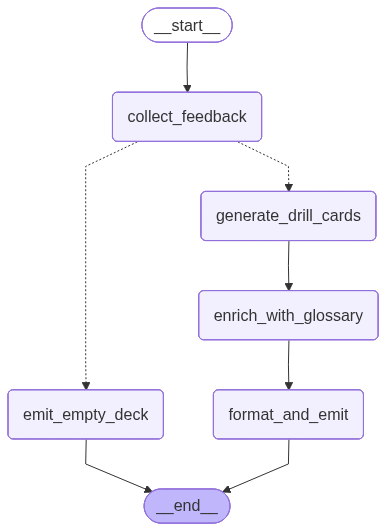

In [9]:
# Visualize the compiled v0 graph.
# Tries Mermaid PNG (uses mermaid.ink — needs network); falls back to ASCII source.
try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"(PNG render unavailable: {e})\n")
    print(app.get_graph().draw_mermaid())

## 8. Smoke run — 2026-04-07 sample

In [10]:
SAMPLE = "~/workspaces/english-feedbacks/feedbacks/2026-04-07.md"
result = app.invoke({
    "target_date": "2026-04-07",
    "feedback_paths": [SAMPLE],
    "raw_entries": [],
    "drill_cards": [],
    "output_paths": {},
})
print("entries parsed: ", len(result["raw_entries"]))
print("drill cards:    ", len(result["drill_cards"]))
print("emitted paths:  ", result["output_paths"])

entries parsed:  4
drill cards:     3
emitted paths:   {'md': 'decks/deck-2026-04-07.md', 'json': 'decks/deck-2026-04-07.json'}


## 9. Display emitted deck

In [11]:
print(Path(result["output_paths"]["md"]).read_text(encoding="utf-8"))

# Drill Deck — 2026-04-07

## Card 1 — `tense`
**Target:** I want to ask you about the code.
**Note:** After "want to," use the base form of the verb ("ask").
**Originally said:** I want to asking you about the code
**Pattern:** Tense / verb form — match the time frame; after modals, 'to', or auxiliaries use the bare infinitive.
**Paraphrases:**
- I would like to ask you about the code.
- I want to inquire about the code.

## Card 2 — `translation`
**Target:** Can you explain how this function works?
**Note:** This is a direct translation from Korean; use natural English phrasing instead.
**Originally said:** 이 함수가 어떻게 동작하는지 설명해줘
**Pattern:** Direct translation from Korean often produces grammatical-but-unnatural English; learn the L2-native phrasing instead.
**Paraphrases:**
- Could you explain how this function operates?
- Can you clarify how this function works?

## Card 3 — `word-choice`
**Target:** I want to make a lightweight agent skill like this English feedback feature.
**Note

## 10. Conditional-edge smoke — empty feedback path

Verify the conditional branch `collect_feedback → emit_empty_deck` triggers when no actionable entries exist.

In [12]:
import tempfile

with tempfile.TemporaryDirectory() as td:
    empty_path = Path(td) / "no-feedback.md"
    empty_path.write_text("# Empty file — no entries here\n", encoding="utf-8")

    empty_result = app.invoke({
        "target_date": "1900-01-01",
        "feedback_paths": [str(empty_path)],
        "raw_entries": [],
        "drill_cards": [],
        "output_paths": {},
    })

print("entries parsed: ", len(empty_result["raw_entries"]))
print("drill cards:    ", len(empty_result["drill_cards"]))
print("emitted paths:  ", empty_result["output_paths"])
print("---")
print(Path(empty_result["output_paths"]["md"]).read_text(encoding="utf-8"))

entries parsed:  0
drill cards:     0
emitted paths:   {'md': 'decks/deck-1900-01-01.md', 'json': ''}
---
# Drill Deck — 1900-01-01

*No actionable feedback found for this date — nothing to drill today.*

